
# Fase 4: Benchmarking Científico de Modelos Unificado
Modelos en competencia directa: 
1. Regresión Logística (Estadística clásica)
2. XGBoost (Ensamble avanzado)
3. LightGBM (Ensamble ultrarrápido)
4. CatBoost (Especialista en variables categóricas)
5. **NUEVO:** Decision Tree (`max_depth=5`)
6. **NUEVO:** Neural Network (`MLPClassifier` 3x200)

Se utiliza Validación Cruzada Estratificada K-Fold (5 particiones) y ajuste demográfico mediante pesos muestrales de la ENDES (`HV005`).


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Cargando el dataset maestro...")
# Ajusta el path relativo según la ubicación de tu entorno
df = pd.read_parquet('../../data/processed/master_preprocessed_v2.parquet')
print(f"Dimensiones de la base de datos: {df.shape}")

# 1. ELIMINAR GEOVARIABLES INNECESARIAS (Ruido para el modelo)
cols_to_drop = [c for c in ['UBIGEO', 'LATITUDY', 'LONGITUDX'] if c in df.columns]
df = df.drop(columns=cols_to_drop)

# 2. IDENTIFICAR Y SEPARAR METADATOS PASIVOS
metadata_cols = ['year', 'SHREGION', 'HV005', 'HV024']
cols_to_extract = [c for c in metadata_cols if c in df.columns]

metadata = df[cols_to_extract].copy()
y = df['TARGET_DESNUTRICION']
X = df.drop(columns=['TARGET_DESNUTRICION'] + cols_to_extract)

# 3. CALCULAR PESO MUESTRAL ENDES
if 'HV005' in metadata.columns:
    sample_weight = metadata['HV005'] / 1000000.0
else:
    sample_weight = pd.Series(np.ones(len(metadata)))

# 4. APLANAR NOMBRES DE COLUMNAS (Para evitar errores en LightGBM/XGBoost)
import sys
import unicodedata
import re

sys.path.append('../../')
try:
    from mnp.configs.column_labels import LABELS
    X = X.rename(columns=LABELS)
except ImportError:
    pass

clean_cols = []
for col in X.columns:
    col_str = unicodedata.normalize('NFKD', str(col)).encode('ASCII', 'ignore').decode('utf-8')
    col_str = re.sub(r'[^a-zA-Z0-9]+', '_', col_str).strip('_')
    clean_cols.append(col_str)
X.columns = clean_cols

print("OK: Dataset preprocesado. Nombres aplanados y pesos muestrales calculados.")


Cargando el dataset maestro...
Dimensiones de la base de datos: (285284, 79)


2026-06-22 02:13:33.764 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /Users/abelguevarah/Desktop/invs/malnutrition-research


OK: Dataset preprocesado. Nombres aplanados y pesos muestrales calculados.


In [2]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Separación de variables por tipo
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Convertir Nulos Categóricos a texto 'Desconocido' (Requisito estricto de CatBoost)
for col in cat_features:
    X[col] = X[col].fillna('Desconocido').astype(str)

# 1. Pipeline para Modelos Clásicos (Regresión Logística, Árboles, Redes Neuronales)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ])

# 2. Formato Nativo optimizado para Modelos Basados en Árboles (XGBoost / LightGBM)
X_boosters = X.copy()
for col in cat_features:
    X_boosters[col] = X_boosters[col].astype('category')
    
print(f"OK: Variables Categóricas: {len(cat_features)}")
print(f"OK: Variables Numéricas: {len(num_features)}")


OK: Variables Categóricas: 35
OK: Variables Numéricas: 39


In [3]:

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

import time
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {'LogReg': {'auc': [], 'recall': [], 'precision': [], 'f1': [], 'time': []},
           'LightGBM': {'auc': [], 'recall': [], 'precision': [], 'f1': [], 'time': []},
           'XGBoost': {'auc': [], 'recall': [], 'precision': [], 'f1': [], 'time': []},
           'CatBoost': {'auc': [], 'recall': [], 'precision': [], 'f1': [], 'time': []},
           'DecisionTree': {'auc': [], 'recall': [], 'precision': [], 'f1': [], 'time': []},
           'NeuralNet': {'auc': [], 'recall': [], 'precision': [], 'f1': [], 'time': []}}

fold5_data = {} # Diccionario crítico para guardar la data del último fold y graficarla sin re-entrenar

print("\nINICIANDO EVALUACIÓN DE MODELOS (5-Fold CV)...")
start_time_global = time.time()

fold = 1
for train_idx, val_idx in kf.split(X, y):
    print(f"\n--- Procesando Fold {fold}/5 ---")
    
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    w_train, w_val = sample_weight.iloc[train_idx], sample_weight.iloc[val_idx]
    
    # Transformaciones para modelos clásicos
    X_train_lr = preprocessor.fit_transform(X.iloc[train_idx])
    X_val_lr = preprocessor.transform(X.iloc[val_idx])
    
    # Transformaciones para ensambles de árboles
    X_train_b, X_val_b = X_boosters.iloc[train_idx], X_boosters.iloc[val_idx]
    
    # --- 1. Regresión Logística ---
    lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
    start_lr = time.time()
    lr.fit(X_train_lr, y_train, sample_weight=w_train)
    lr_probs = lr.predict_proba(X_val_lr)[:, 1]
    time_lr = time.time() - start_lr
    
    # --- 2. LightGBM ---
    lgbm = lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1, n_estimators=300)
    start_lgb = time.time()
    lgbm.fit(X_train_b, y_train, sample_weight=w_train)
    lgb_probs = lgbm.predict_proba(X_val_b)[:, 1]
    time_lgb = time.time() - start_lgb
    
    # --- 3. XGBoost ---
    scale_pos = (len(y_train) - y_train.sum()) / y_train.sum()
    xg = xgb.XGBClassifier(scale_pos_weight=scale_pos, min_child_weight=1e-7, random_state=42, n_estimators=300)
    start_xgb = time.time()
    xg.fit(X_train_lr, y_train, sample_weight=w_train, verbose=False)
    xgb_probs = xg.predict_proba(X_val_lr)[:, 1]
    time_xgb = time.time() - start_xgb
    
    # --- 4. CatBoost ---
    cat = cb.CatBoostClassifier(auto_class_weights='Balanced', cat_features=cat_features, random_state=42, iterations=300, verbose=False)
    start_cat = time.time()
    cat.fit(X.iloc[train_idx], y_train, sample_weight=w_train, verbose=False)
    cat_probs = cat.predict_proba(X.iloc[val_idx])[:, 1]
    time_cat = time.time() - start_cat
    
    # --- 5. Decision Tree (Nueva Exigencia) ---
    dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
    start_dt = time.time()
    dt.fit(X_train_lr, y_train, sample_weight=w_train)
    dt_probs = dt.predict_proba(X_val_lr)[:, 1]
    time_dt = time.time() - start_dt
    
    # --- 6. Neural Network (Nueva Exigencia) ---
    # Nota: Scikit-learn MLPClassifier no soporta sample_weight ni class_weight nativo.
    mlp = MLPClassifier(hidden_layer_sizes=(200, 200, 200), max_iter=50, random_state=42, early_stopping=True)
    start_mlp = time.time()
    mlp.fit(X_train_lr, y_train)
    mlp_probs = mlp.predict_proba(X_val_lr)[:, 1]
    time_mlp = time.time() - start_mlp
    
    # --- Evaluación de Probabilidades ---
    models_probs = {
        'LogReg': lr_probs, 'LightGBM': lgb_probs, 'XGBoost': xgb_probs, 
        'CatBoost': cat_probs, 'DecisionTree': dt_probs, 'NeuralNet': mlp_probs
    }
    
    for name, probs in models_probs.items():
        auc_score = roc_auc_score(y_val, probs, sample_weight=w_val)
        recall = recall_score(y_val, (probs >= 0.5).astype(int), sample_weight=w_val)
        precision = precision_score(y_val, (probs >= 0.5).astype(int), sample_weight=w_val, zero_division=0)
        f1 = f1_score(y_val, (probs >= 0.5).astype(int), sample_weight=w_val, zero_division=0)
        
        results[name]['auc'].append(auc_score)
        results[name]['recall'].append(recall)
        results[name]['precision'].append(precision)
        results[name]['f1'].append(f1)
        time_dict = {'LogReg': time_lr, 'LightGBM': time_lgb, 'XGBoost': time_xgb, 'CatBoost': time_cat, 'DecisionTree': time_dt, 'NeuralNet': time_mlp}
        results[name]['time'].append(time_dict[name])
        print(f"  - {name.ljust(15)}: AUC = {auc_score:.4f} | Recall = {recall:.4f} | Prec = {precision:.4f} | F1 = {f1:.4f} | Tiempo = {time_dict[name]:.2f}s")
        
    # Guardamos los resultados del último ciclo para poder graficarlos después
    if fold == 5:
        fold5_data = {'y_val': y_val, 'w_val': w_val, 'probs': models_probs}
        
    fold += 1

total_time = time.time() - start_time_global
print(f"\nENTRENAMIENTO FINALIZADO. Tiempo Total: {total_time/60:.2f} minutos.")



INICIANDO EVALUACIÓN DE MODELOS (5-Fold CV)...

--- Procesando Fold 1/5 ---
  - LogReg         : AUC = 0.7916 | Recall = 0.7185 | Prec = 0.3439 | F1 = 0.4651 | Tiempo = 1.38s
  - LightGBM       : AUC = 0.8300 | Recall = 0.7630 | Prec = 0.3710 | F1 = 0.4992 | Tiempo = 4.30s
  - XGBoost        : AUC = 0.7939 | Recall = 0.7551 | Prec = 0.3339 | F1 = 0.4631 | Tiempo = 5.69s
  - CatBoost       : AUC = 0.8298 | Recall = 0.2963 | Prec = 0.6089 | F1 = 0.3986 | Tiempo = 92.65s
  - DecisionTree   : AUC = 0.7809 | Recall = 0.6996 | Prec = 0.3385 | F1 = 0.4563 | Tiempo = 4.26s
  - NeuralNet      : AUC = 0.8224 | Recall = 0.2130 | Prec = 0.6219 | F1 = 0.3173 | Tiempo = 170.91s

--- Procesando Fold 2/5 ---
  - LogReg         : AUC = 0.7888 | Recall = 0.7126 | Prec = 0.3373 | F1 = 0.4578 | Tiempo = 1.21s
  - LightGBM       : AUC = 0.8263 | Recall = 0.7590 | Prec = 0.3663 | F1 = 0.4941 | Tiempo = 3.60s
  - XGBoost        : AUC = 0.7921 | Recall = 0.7527 | Prec = 0.3266 | F1 = 0.4555 | Tiempo = 5.28s


In [4]:

summary = []
for name, metrics in results.items():
    summary.append({
        'Modelo': name,
        'AUC Promedio': np.mean(metrics['auc']),
        'AUC Std': np.std(metrics['auc']),
        'Recall Promedio': np.mean(metrics['recall']),
        'Precision Promedio': np.mean(metrics['precision']),
        'F1-Score Promedio': np.mean(metrics['f1']),
        'Tiempo Entrenamiento (s)': np.mean(metrics['time'])
    })

res_df = pd.DataFrame(summary).sort_values(by='AUC Promedio', ascending=False).reset_index(drop=True)
print(" TABLA DE POSICIONES FINAL ")
display(res_df)


 TABLA DE POSICIONES FINAL 


,Modelo,AUC Promedio,AUC Std,Recall Promedio,Precision Promedio,F1-Score Promedio,Tiempo Entrenamiento (s)
0,LightGBM,0.830680,0.003497,0.763758,0.368976,0.497555,3.714401
1,CatBoost,0.830213,0.003741,0.299884,0.609918,0.402053,88.205502
2,NeuralNet,0.821905,0.003075,0.251238,0.611639,0.355438,115.782909
3,XGBoost,0.793674,0.001775,0.757348,0.327548,0.457288,5.391712
4,LogReg,0.792370,0.002732,0.716687,0.339654,0.460879,1.232178
5,DecisionTree,0.781717,0.001560,0.717562,0.328968,0.450931,4.313718



### Análisis Gráfico Comparativo
Graficamos la Curva ROC y la Curva Precision-Recall de los 6 modelos utilizando las probabilidades predichas del último Fold de validación.


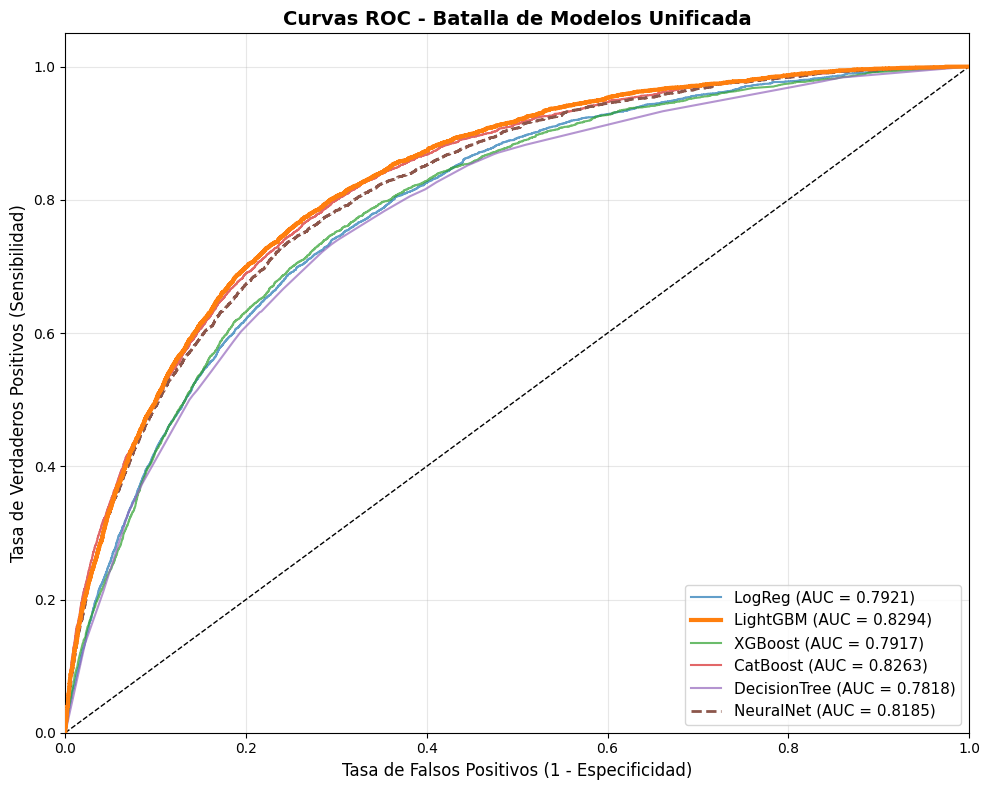

In [5]:

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# Extraemos la data guardada de la iteración 5
y_test_plot = fold5_data['y_val']
w_test_plot = fold5_data['w_val']
probs_plot = fold5_data['probs']

for name, probs in probs_plot.items():
    fpr, tpr, _ = roc_curve(y_test_plot, probs, sample_weight=w_test_plot)
    roc_auc = auc(fpr, tpr)
    
    if name == 'LightGBM':
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', linewidth=3, zorder=10)
    elif name == 'NeuralNet':
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', linewidth=2, linestyle='--')
    else:
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', alpha=0.7)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
plt.title('Curvas ROC - Batalla de Modelos Unificada', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


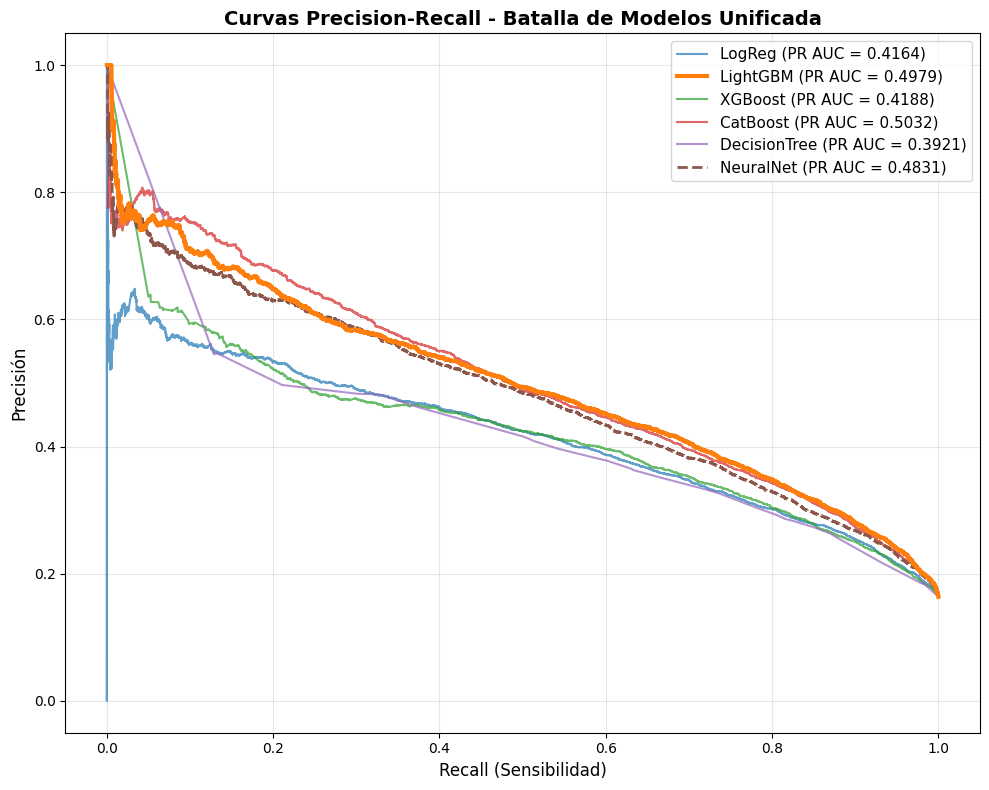

In [6]:

from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 8))

for name, probs in probs_plot.items():
    precision, recall, _ = precision_recall_curve(y_test_plot, probs, sample_weight=w_test_plot)
    pr_auc = average_precision_score(y_test_plot, probs, sample_weight=w_test_plot)
    
    if name == 'LightGBM':
        plt.plot(recall, precision, label=f'{name} (PR AUC = {pr_auc:.4f})', linewidth=3, zorder=10)
    elif name == 'NeuralNet':
        plt.plot(recall, precision, label=f'{name} (PR AUC = {pr_auc:.4f})', linewidth=2, linestyle='--')
    else:
        plt.plot(recall, precision, label=f'{name} (PR AUC = {pr_auc:.4f})', alpha=0.7)

plt.xlabel('Recall (Sensibilidad)', fontsize=12)
plt.ylabel('Precisión', fontsize=12)
plt.title('Curvas Precision-Recall - Batalla de Modelos Unificada', fontsize=14, fontweight='bold')
plt.legend(loc="upper right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



---
# Fase 5: Selección Estricta de Variables por Umbral de Importancia
En lugar de aislar un "Top 10" estático, entrenaremos al modelo ganador en toda la base de datos para extraer los **pesos algorítmicos (Feature Importance)** reales de cada variable de la ENDES.
Luego, evaluaremos el desempeño clínico del modelo utilizando únicamente los subconjuntos que hayan superado las barreras matemáticas de peso `>= 10`, `>= 30` y `>= 50`.


In [7]:

print(" Entrenando Modelo Campeón para extraer el Peso Matemático de las 76 Variables...")
lgbm_master = lgb.LGBMClassifier(class_weight='balanced', random_state=42, n_estimators=300)
lgbm_master.fit(X_boosters, y, sample_weight=sample_weight)

importance = lgbm_master.feature_importances_
feature_names = X_boosters.columns

# Empaquetar y ordenar de mayor a menor importancia
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Extraer los nombres de las variables que superen los umbrales exigidos
feats_ge_10 = feat_imp_df[feat_imp_df['Importance'] >= 10]['Feature'].tolist()
feats_ge_30 = feat_imp_df[feat_imp_df['Importance'] >= 30]['Feature'].tolist()
feats_ge_50 = feat_imp_df[feat_imp_df['Importance'] >= 50]['Feature'].tolist()

print("\n RESUMEN DE FILTRADO:")
print(f" Variables con Peso Algorítmico >= 10 : {len(feats_ge_10)} variables")
print(f" Variables con Peso Algorítmico >= 30 : {len(feats_ge_30)} variables")
print(f" Variables con Peso Algorítmico >= 50 : {len(feats_ge_50)} variables")
print(f" Total de Variables de la ENDES       : {len(X_boosters.columns)} variables")

subsets = {
    'Umbral Peso >= 10': feats_ge_10,
    'Umbral Peso >= 30': feats_ge_30,
    'Umbral Peso >= 50': feats_ge_50,
    'Todas (Original)': X_boosters.columns.tolist()
}


 Entrenando Modelo Campeón para extraer el Peso Matemático de las 76 Variables...

 RESUMEN DE FILTRADO:
 Variables con Peso Algorítmico >= 10 : 43 variables
 Variables con Peso Algorítmico >= 30 : 33 variables
 Variables con Peso Algorítmico >= 50 : 25 variables
 Total de Variables de la ENDES       : 74 variables


In [10]:

print(" INICIANDO EVALUACIÓN CLÍNICA DE SUBCONJUNTOS (K-Fold CV)...")
results_fs = {}

for subset_name, feats in subsets.items():
    print(f"\n========================================")
    print(f"Evaluando Escenario: {subset_name} ({len(feats)} vars)")
    print(f"========================================")
    
    # Recortar el dataset solo a las variables filtradas
    X_sub = X_boosters[feats]
    
    subset_auc = []
    subset_recall = []
    
    fold = 1
    for train_idx, val_idx in kf.split(X_sub, y):
        X_train_sub, X_val_sub = X_sub.iloc[train_idx], X_sub.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        w_train, w_val = sample_weight.iloc[train_idx], sample_weight.iloc[val_idx]
        
        # Entrenar LightGBM en el subconjunto recortado
        lgbm_sub = lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1, n_estimators=300)
        lgbm_sub.fit(X_train_sub, y_train, sample_weight=w_train)
        probs_sub = lgbm_sub.predict_proba(X_val_sub)[:, 1]
        
        auc_score = roc_auc_score(y_val, probs_sub, sample_weight=w_val)
        recall = recall_score(y_val, (probs_sub >= 0.5).astype(int), sample_weight=w_val)
        
        subset_auc.append(auc_score)
        subset_recall.append(recall)
        fold += 1
        
    mean_auc = np.mean(subset_auc)
    mean_recall = np.mean(subset_recall)
    results_fs[subset_name] = {'AUC Promedio': mean_auc, 'Recall Promedio': mean_recall, 'N_Variables': len(feats)}
    print(f" Resultado Final {subset_name}: AUC = {mean_auc:.4f} | Recall = {mean_recall:.4f}")

print("\n EXPERIMENTOS FINALIZADOS")


 INICIANDO EVALUACIÓN CLÍNICA DE SUBCONJUNTOS (K-Fold CV)...

Evaluando Escenario: Umbral Peso >= 10 (43 vars)
 Resultado Final Umbral Peso >= 10: AUC = 0.8308 | Recall = 0.7649

Evaluando Escenario: Umbral Peso >= 30 (33 vars)
 Resultado Final Umbral Peso >= 30: AUC = 0.8302 | Recall = 0.7648

Evaluando Escenario: Umbral Peso >= 50 (25 vars)
 Resultado Final Umbral Peso >= 50: AUC = 0.8292 | Recall = 0.7639

Evaluando Escenario: Todas (Original) (74 vars)
 Resultado Final Todas (Original): AUC = 0.8307 | Recall = 0.7638

 EXPERIMENTOS FINALIZADOS


In [9]:

res_fs_df = pd.DataFrame(results_fs).T
print(" IMPACTO DE REDUCCIÓN DE VARIABLES (RUIDO ESTADÍSTICO) ")
display(res_fs_df)


 IMPACTO DE REDUCCIÓN DE VARIABLES (RUIDO ESTADÍSTICO) 


,AUC Promedio,Recall Promedio,N_Variables
Umbral Peso >= 10,0.830779,0.764914,43.0
Umbral Peso >= 30,0.830158,0.764796,33.0
Umbral Peso >= 50,0.829152,0.763877,25.0
Todas (Original),0.830680,0.763758,74.0
